In [1]:
%load_ext autoreload
%autoreload 2

# **Análisis Exploratorio de Datos** (EDA)

---

In [2]:
import sys
sys.path.append("..")

from sklearn.metrics import cohen_kappa_score, confusion_matrix

from src.data import EDA, STAGES_LABELS
import src.plots as plots
import src.metrics as metrics

c:\Users\agust\anaconda3\envs\pf_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset: **BIDSleep**

Se compone de datos de 47 pacientes (BidslabXX) sanos con grabaciones de entre 3 a 7 noches de (1) la frecuencia cardiaca instantánea (IHR) y (2) 3 ejes de acelerometría medidos por un Apple Watch con un total de 253 noches de datos. Cada época (lapsos de 30 segundos) vienen etiquetados por un experto (*expert_label*) y el dispotitivo "Dreem 2 Headband" (*dreem_label*), un monitor de sueño portátil.

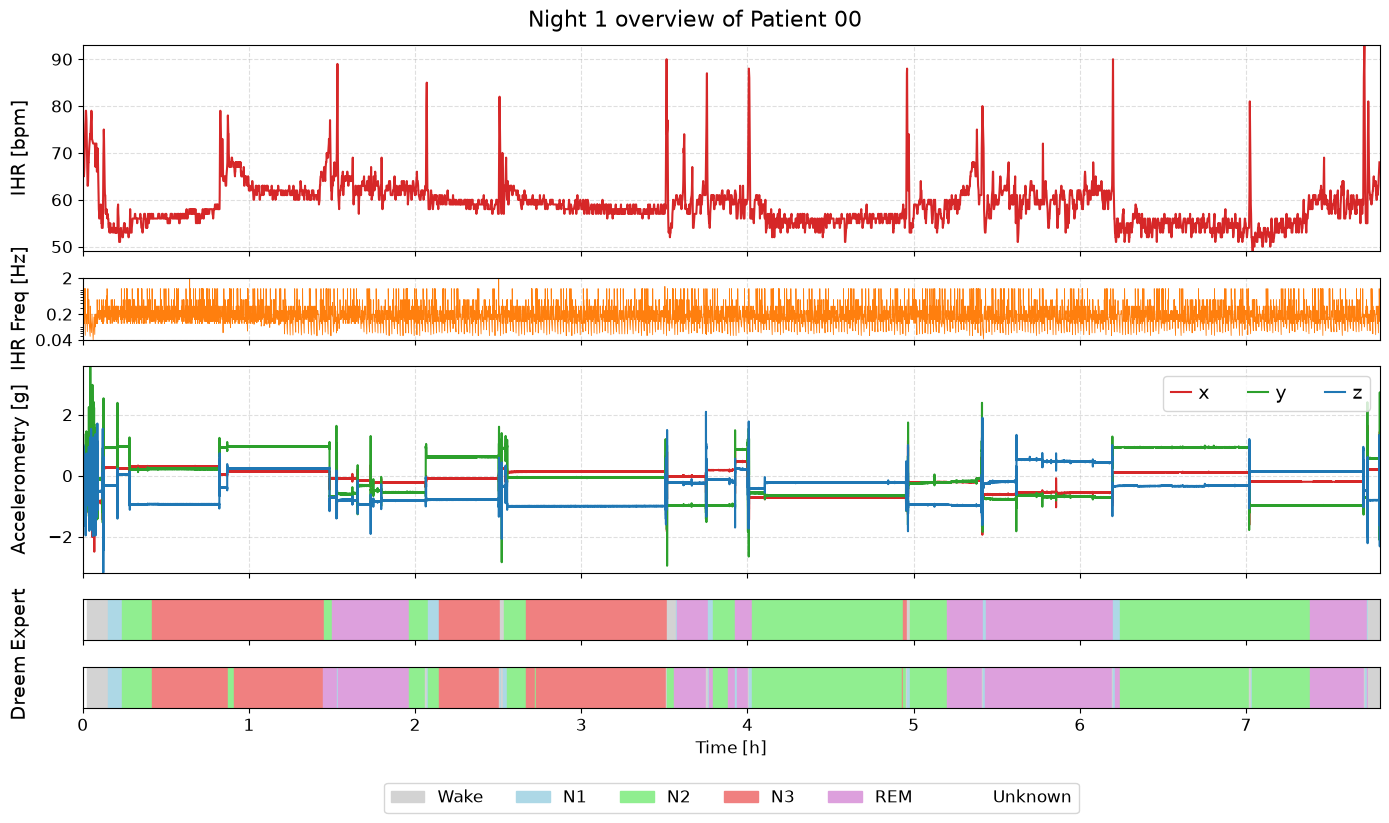

In [3]:
patient, night = 0, 1
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

Encontramos noches con datos inconsistentes y/o mal condicionados como por ejemplo el siguiente en el que los timestamps indican una duración de $\sim30$ horas, por lo que debimos analizar la calidad de cada noche.

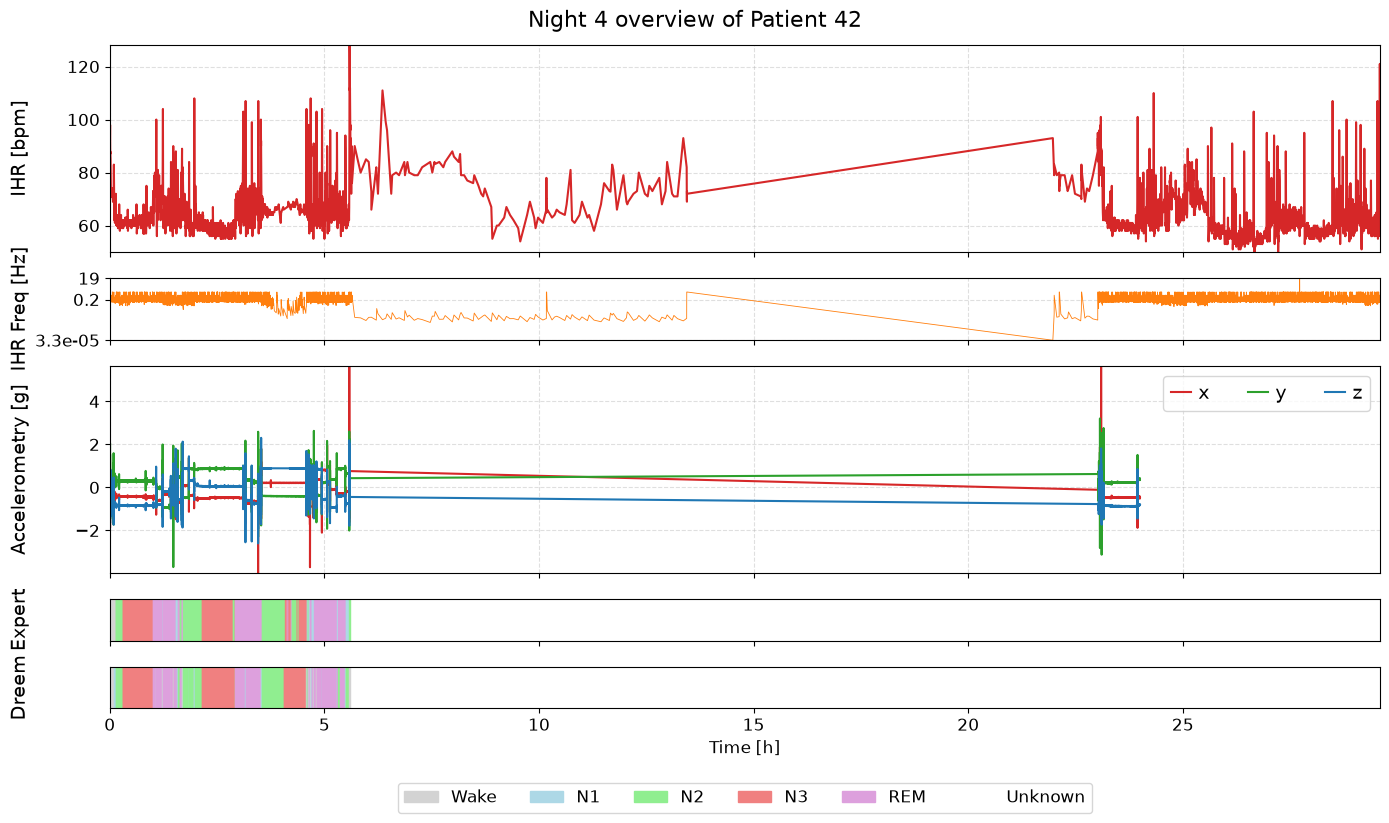

In [4]:
patient, night = 42, 4
night_data = EDA.load_night(patient, night)
plots.night_overview(night_data, patient, night)

## Evaluación de calidad de los datos.

El test de calidad define la **ventana válida** de cada noche a partir de la extensión del etiquetado del experto (`expert_label`). Pero cada noche tiene además el etiquetado del dispositivo Dreem (`dreem_label`), y ambos no tienen por qué cubrir exactamente el mismo lapso temporal. Antes de definir la ventana válida verificamos entonces en cuántas noches difieren en extensión `expert_label` y `dreem_label`, y por cuánto.

In [5]:
mismatches = EDA.label_length_mismatch()

print(f'Noches con distinta extensión entre expert y dreem: {len(mismatches)} / 253\n')
for m in mismatches:
    print(f"Paciente {m['patient']:02d} Noche {m['night']}: "
          f"expert = {m['n_expert']} epochs, dreem = {m['n_dreem']} epochs "
          f"(dif {m['diff_epochs']:+d} epochs = {m['diff_s']:+d}s)")

Noches con distinta extensión entre expert y dreem: 2 / 253

Paciente 01 Noche 4: expert = 771 epochs, dreem = 935 epochs (dif +164 epochs = +4920s)
Paciente 30 Noche 6: expert = 851 epochs, dreem = 849 epochs (dif -2 epochs = -60s)


En **251 de las 253 noches** ambos etiquetados tienen exactamente la misma extensión, y sólo difieren en dos casos:

- **Paciente 01 Noche 4**: `expert` cubre 771 epochs y `dreem` 935 (dreem se extiende 164 epochs = 1.37h más). Como `expert` es el más corto, su ventana queda **contenida** en la de dreem.
- **Paciente 30 Noche 6**: `expert` cubre 851 epochs y `dreem` 849 (expert se excede en apenas 2 epochs = 60s).

Tomando la ventana válida según `expert_label` cubrimos siempre el lapso etiquetado por ambos: en P01 N4 la ventana de expert está incluida en la de dreem, y en P30 N6 el exceso es de sólo 60s (1 noche, despreciable). Como además el test de calidad evalúa la cobertura de HR sobre las etiquetas del experto, **`expert_label` define la ventana válida** usada en el análisis que sigue.

`EDA.quality_report()` recorre las 253 noches y calcula, para cada una, métricas de calidad de señal:

- **Gaps temporales** en `hr.csv` y `motion.csv`: intervalos entre muestras consecutivas mayores a $\texttt{GAP\_THRESHOLD\_S} = 60s$, que indican períodos sin medición (el dispositivo interpola linealmente los valores faltantes en ese rango).
- **Duración total** (`hr_span_h`): horas que abarca la señal de `hr.csv`. Una noche dura $\approx$ 8h; valores muy por encima indican que el registro se extiende más allá de la ventana etiquetada (ese exceso se trunca al construir el dataset). Es una métrica informativa, no un criterio de descarte.
- **Valores NaN** (`hr_nan_count`, `motion_nan_count`): filas con datos faltantes en cada señal.
- **Acelerometría inválida**: fracción de muestras donde $|\sqrt{x^2+y^2+z^2} - 1| > \texttt{ACC\_TOL} = 0.5g$. En reposo, la norma del vector de aceleración debería ser exactamente $1g$ (gravedad); sin embargo, desviaciones grandes también ocurren por movimiento real del cuerpo, por lo que no se usa como criterio de descarte.
- **IHR inválido**: muestras con $\texttt{hr <= 0}$ ó $\texttt{hr > 200 bpm}$ (excluyendo los bordes de la grabación).

A partir de estas métricas definimos la **ventana válida** de cada noche: la intersección entre la ventana etiquetada $[\texttt{recStart},\ \texttt{recStart} + \texttt{label\_span\_s}]$ y el rango de señal **continua** de **ambas** señales, `hr.csv` **y** `motion.csv` (acelerometría). Los modelos usan IHR *y* acelerometría, así que un tramo con una sola de las dos no es válido — típicamente la acelerometría muere antes que el IHR al final de la noche, y la ventana se recorta ahí. Un gap cuya señal sólo reanuda *fuera* del etiquetado (noches que siguen grabando de día) se trata como borde, no como discontinuidad interna, para hr y para motion. Comparando la señal con la ventana etiquetada surgen cinco desajustes posibles:

- **`leading_trunc_s` / `trailing_trunc_s`**: labels sin señal al inicio / fin (la ventana etiquetada se extiende más allá de la señal continua).
- **`head_excess_s` / `tail_excess_s`**: señal sin label antes / después del etiquetado (la señal se extiende más allá de las labels).
- **`internal_gap_s`** (y `motion_internal_gap_s`): suma de gaps de `hr.csv` (resp. `motion.csv`) *dentro* de la ventana válida, recortados a esa ventana — discontinuidades en medio de la secuencia, con datos a ambos lados.

**Una noche es problemática si requiere alguna modificación**, es decir, si la señal y las labels no cubren exactamente el mismo período (más allá de `ALIGN_TOL_S = 30s`, una epoch). Sólo las noches ya alineadas quedan fuera. Cada noche problemática se etiqueta con el tipo de modificación que necesita:

1. **`signal_excess`** (`head_excess_s` / `tail_excess_s`): hay señal fuera del etiquetado. **Solución: recortar la señal** (no puede haber muestras sin label). Es la modificación más común y trivial.
2. **`label_trunc`** (`leading_trunc_s` / `trailing_trunc_s`): hay labels sin señal. **Solución: recortar las labels** (no puede haber epochs etiquetadas sin señal).
3. **`internal_gap`** (`internal_gap_s > INTERNAL_GAP_THRESHOLD_S = 10min`): discontinuidad real del **IHR** dentro de la ventana válida, que no se resuelve truncando bordes. **Solución: descartar o reparar** la noche; se decide al construir el dataset. (Los dropouts de acelerometría, en cambio, no descartan la noche: se resuelven dropeando esas épocas puntuales — ver más abajo.)

La lista completa se guarda en `analysis/problematic_nights.json`. Todas las modificaciones se aplican en memoria al construir el dataset, sin modificar los archivos originales (el notebook es reproducible).

In [6]:
EDA.quality_report()

Paciente 68 - Noche 4: 100%|██████████| 253/253 [03:54<00:00,  1.08it/s]


In [7]:
import pandas as pd
import json
from collections import Counter

with open('../analysis/quality_report.json', 'r', encoding='utf-8') as f:
    records = json.load(f)
df_quality = pd.DataFrame(records).drop(columns=['hr_gaps', 'motion_gaps'], errors='ignore')
problematic_nights = EDA.problematic_nights(df_quality)
 
print(f'Noches que requieren modificación: {len(problematic_nights)} / {len(df_quality)} '
      f'({100*len(problematic_nights)/len(df_quality):.1f}%)')

combos = Counter(tuple(n['modifications']) for n in problematic_nights)
for combo, count in combos.most_common():
    print(f'  {count:3d}  {" + ".join(combo)}')

Noches que requieren modificación: 229 / 253 (90.5%)
   88  signal_excess + label_trunc
   73  signal_excess
   67  label_trunc
    1  signal_excess + label_trunc + internal_gap


El `.json` lista **todas** las noches que requieren alguna modificación (229 de 253; sólo 24 ya están alineadas), cada una con su tipo de modificación. La mayoría son simple `signal_excess` (señal sobrante fuera del etiquetado, que se recorta trivialmente) o `label_trunc`, o la combinación de ambas.

El overview de abajo grafica sólo el subconjunto que **pierde labels o tiene gaps** (truncamiento de extremo $>1h$ o gap interno), que es lo interesante de inspeccionar. En cada gráfico, la **ventana válida** (lo que se conserva) se sombrea en verde con sus bordes marcados; los labels sin señal que se recortan, en naranja; y los gaps internos, en rojo. El rótulo indica la métrica significativa de cada caso.

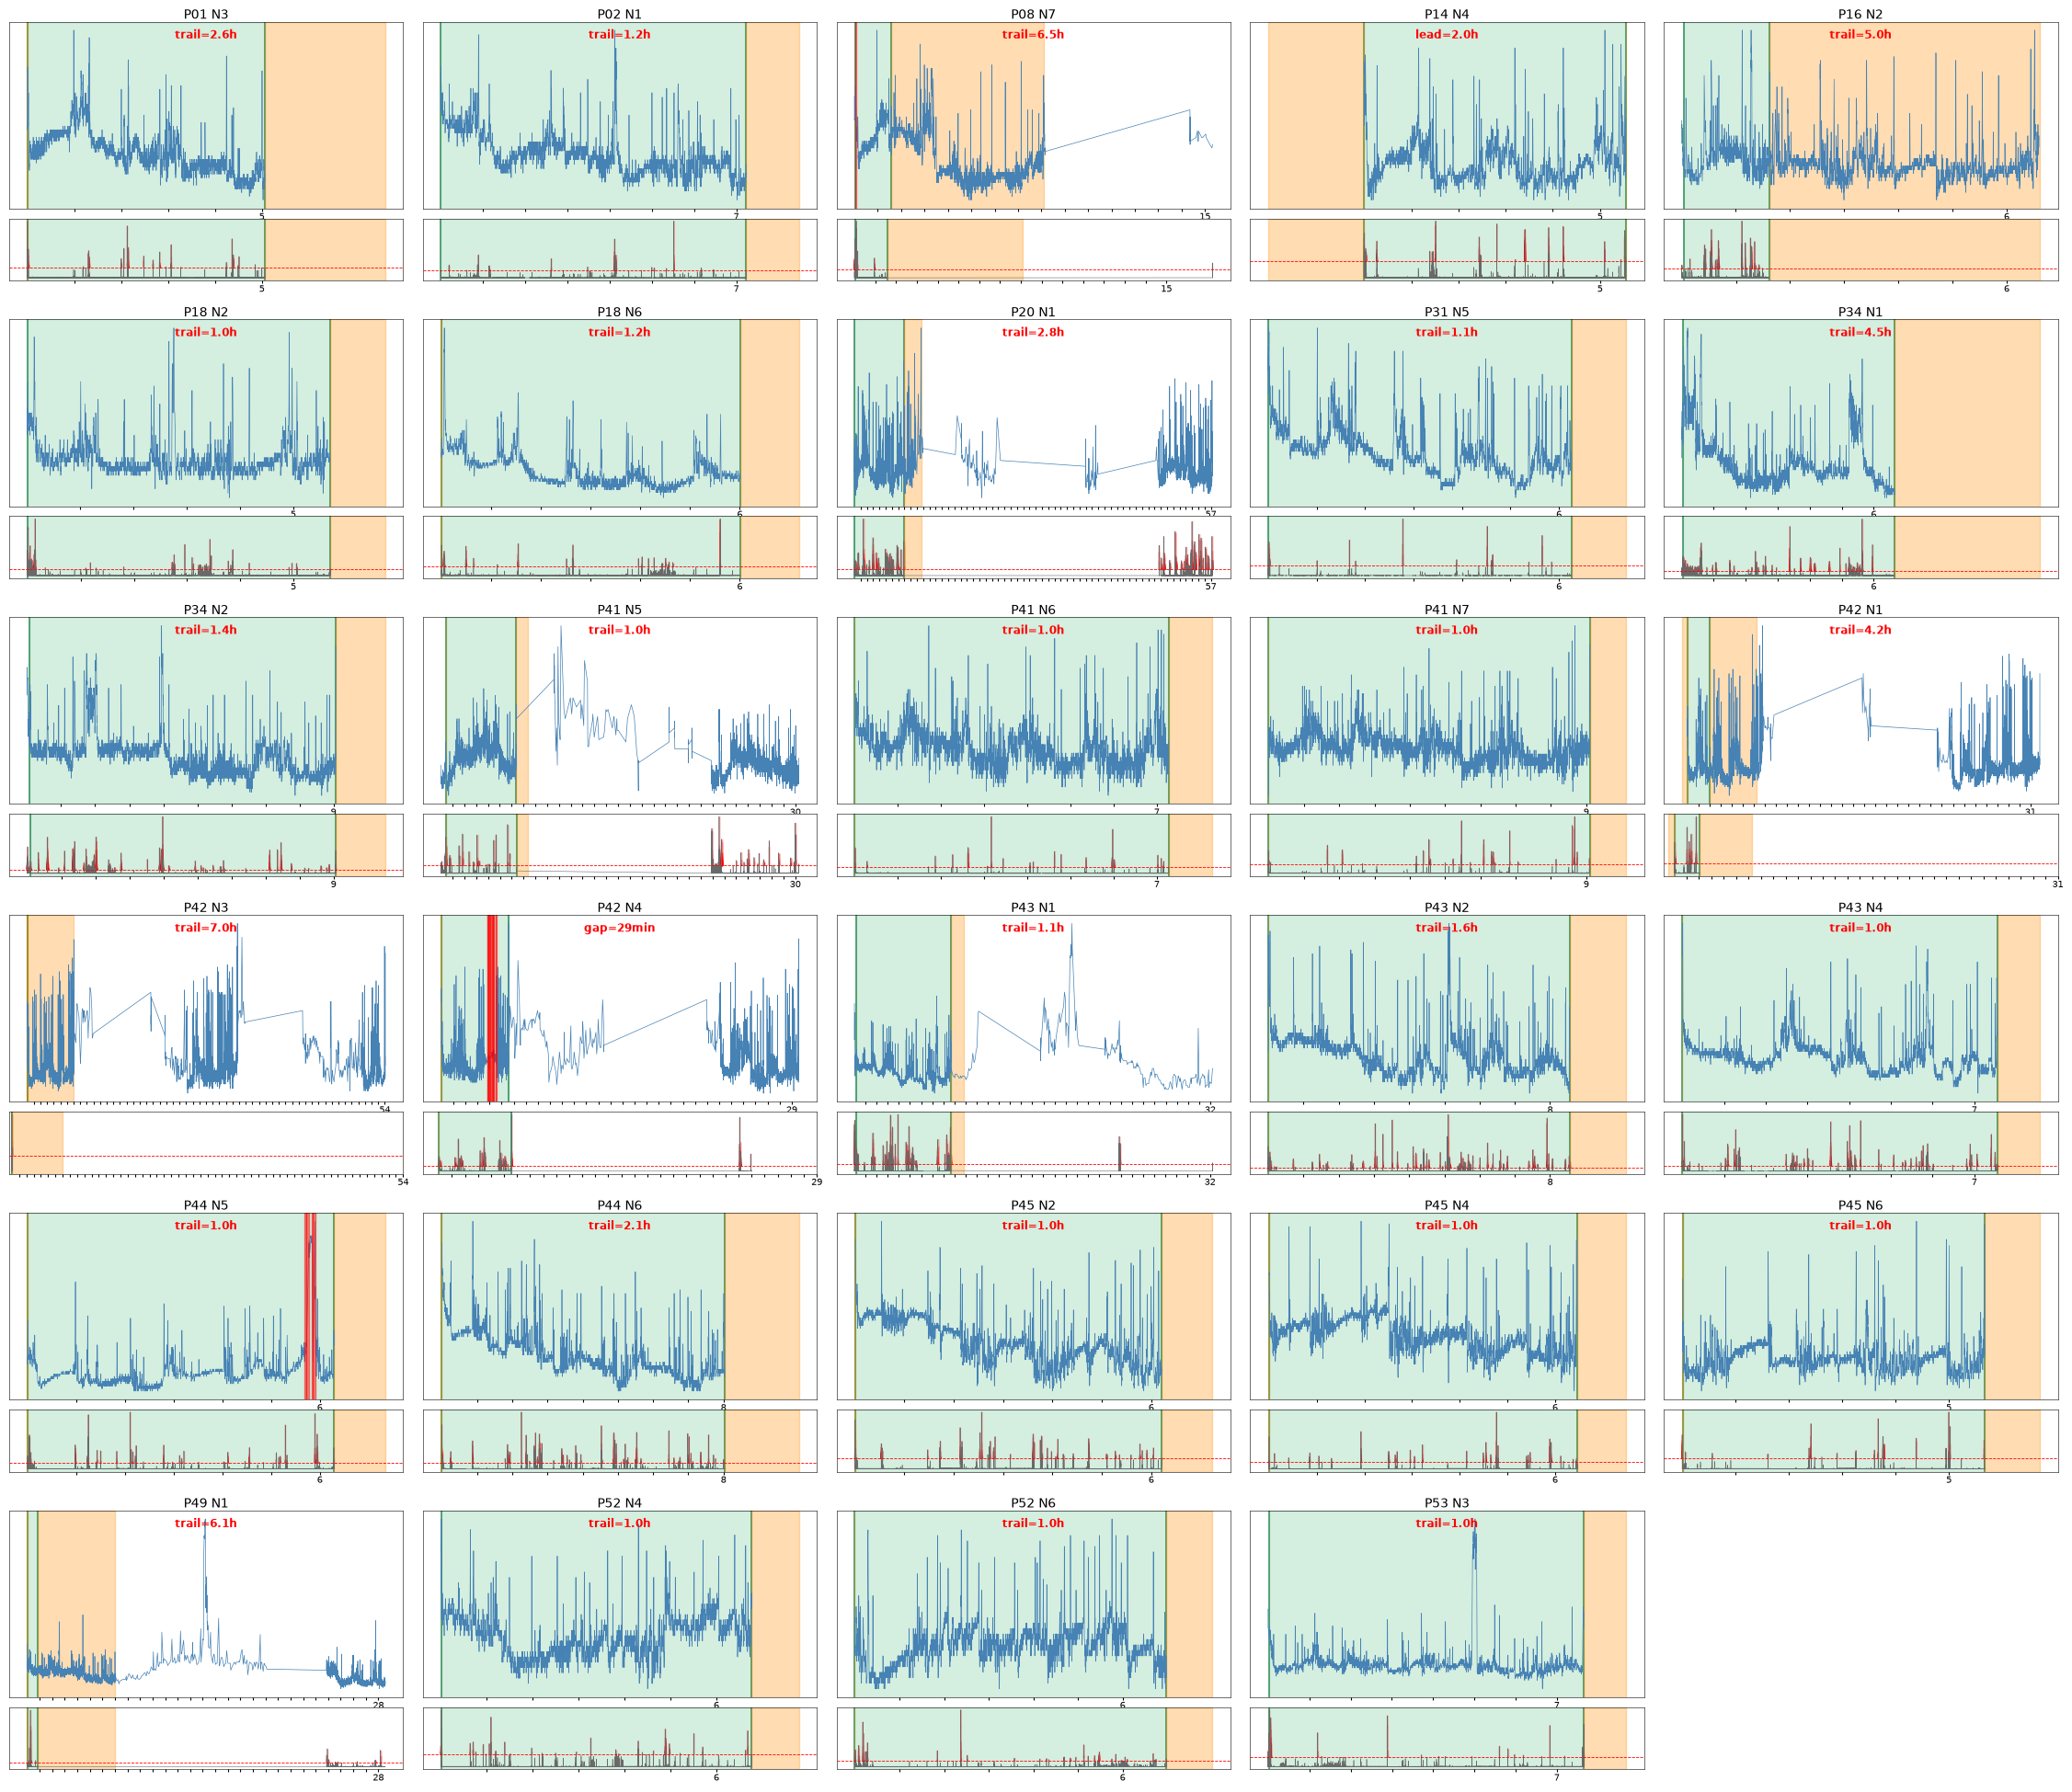

In [8]:
plots.problematic_nights_overview(ncols=5)

### Manejo de gaps internos

Entre las modificaciones, `internal_gap` (gaps de **IHR** *dentro* de la ventana válida) es la única que no se resuelve recortando bordes: hay un hueco de medición en el medio de la noche, con datos a ambos lados. Con la ventana acotada por **ambas** señales (hr ∩ acc), la mayoría de los gaps de IHR quedan *fuera* de la ventana (IHR y acelerometría suelen morir juntos al final de la noche, y ese tramo ya se recorta), así que **sólo 1 noche** conserva un gap interno genuino de IHR: **P42 N4**.

Antes de decidir qué hacer, testeamos una hipótesis: ¿es el gap un artefacto de *timestamps* (el reloj saltó de hora pero la señal subyacente es continua)? Si así fuera, al "colapsar" el hueco la frecuencia cardíaca a ambos lados sería prácticamente continua (salto comparable al $|\Delta\text{HR}|$ típico entre samples consecutivos, ~1–5 bpm). Medimos el salto de HR a través del gap y la cobertura de cada época (una época está *cubierta* si su ventana de 30 s contiene al menos un sample de HR):

In [9]:
import numpy as np
from src.data import EDA, GAP_THRESHOLD_S, INTERNAL_GAP_THRESHOLD_S

ig = df_quality[df_quality['internal_gap_s'] > INTERNAL_GAP_THRESHOLD_S]
rows = []
for _, r in ig.iterrows():
    p, n = int(r['patient']), int(r['night'])
    hr, _, _, expert, al = EDA.load_night_clean(p, n, r['valid_start_s'], r['valid_end_s'])
    ts, v = hr['Timestamp'].values, hr['hr'].values
    gi = np.where(np.diff(ts) > GAP_THRESHOLD_S)[0]      # indices de gaps internos
    jump = np.abs(v[gi + 1] - v[gi])                     # salto de HR a traves del hueco
    n_ep = len(expert)
    starts = al + np.arange(n_ep) * 30
    covered = np.searchsorted(ts, starts + 30) > np.searchsorted(ts, starts)
    unc = np.where(~covered)[0]
    rows.append({
        'patient': p, 'night': n, 'n_epochs': n_ep,
        'epochs_sin_cobertura': len(unc),
        '%_sin_cob': round(100 * len(unc) / n_ep, 1),
        'salto_HR_max_bpm': round(float(jump.max()), 1),
        'gap_frac_min': round(float(unc.min() / n_ep), 2),
        'gap_frac_max': round(float(unc.max() / n_ep), 2),
    })
gaps_df = pd.DataFrame(rows)
display(gaps_df)

# politica de resolucion: recortar la cola si el prefijo limpio es grande, descartar si no
resolution = EDA.internal_gap_resolution(df_quality)
for (p, n), info in resolution.items():
    print(f'P{p:02d} N{n}: {info["action"]:9s}  prefijo limpio contiguo = {info["clean_prefix_frac"]:.0%}')

,patient,night,n_epochs,epochs_sin_cobertura,%_sin_cob,salto_HR_max_bpm,gap_frac_min,gap_frac_max
0,42,4,670,48,7.2,7.0,0.3,0.81


P42 N4: discard    prefijo limpio contiguo = 30%


**Conclusión.** El gap interno de **P42 N4** no es un artefacto de *timestamps* colapsable: aunque el salto de HR a través del hueco es chico (~7 bpm), hay ~29 min **sin ninguna medición en el medio** de la noche (épocas sin cobertura entre el 30 % y el 81 % de la noche). No se puede fabricar la señal faltante, y correr los samples posteriores desalinearía las labels (ancladas a tiempo absoluto, 30 s por época). Un hueco intermedio, además, rompe la dependencia temporal que un LSTM/BiLSTM pretende capturar. Por eso P42 N4 se **descarta** entera (`discard`): el prefijo contiguo cubierto es sólo 30 %, por debajo de `MIN_CLEAN_PREFIX_FRAC = 0.6`.

Las otras noches que con el criterio anterior (sólo-IHR) aparecían con gap interno (**P20 N1, P43 N1, P43 N3**) ya no lo hacen: sus huecos estaban en la **cola**, donde el IHR seguía vivo pero la acelerometría ya había muerto. Al acotar la ventana válida también por la acelerometría, esa cola queda **fuera** de la ventana (no hay nada que "reparar"), y los dropouts de acc **dispersos** que caen dentro se resuelven dropeando esas épocas puntuales — el filtro por época (`IHR≥2` y `acc≥10`) de `feature_extraction` / `build_night_sequences` —, sin tirar la noche entera.

Esta política la implementan `EDA.internal_gap_resolution` (decisión `trim_tail` / `discard` según la continuidad del IHR, umbral de prefijo limpio `MIN_CLEAN_PREFIX_FRAC = 0.6`) y el filtro por época del pipeline. Resultado: se **descarta 1 noche** (P42 N4) y se conservan las demás recortando sólo lo inválido (la cola sin acelerometría y las épocas sueltas sin cobertura). El gráfico de *cruda vs procesada* de abajo hace visible ese recorte noche a noche.

### Cruda vs procesada (una noche)

`plots.raw_vs_clean_overview(patient, night)` muestra, para una noche, la señal **cruda** y el efecto del **procesamiento**: IHR y acelerometría con la **ventana válida** sombreada en verde (lo removido, en gris), más el hipnograma del experto **antes** (`Expert (cruda)`) y **después** (`Expert (procesada)`), donde las épocas descartadas —fuera de la ventana o sin cobertura de ambas señales (`IHR<2` o `acc<10`)— quedan en blanco.

Se ve, por ejemplo, cómo en **P20 N1** la acelerometría muere antes que el IHR y la ventana se recorta ahí (las épocas del final quedan descartadas aunque tengan IHR), y cómo una noche con gap interno de IHR (**P42 N4**) se descarta entera.

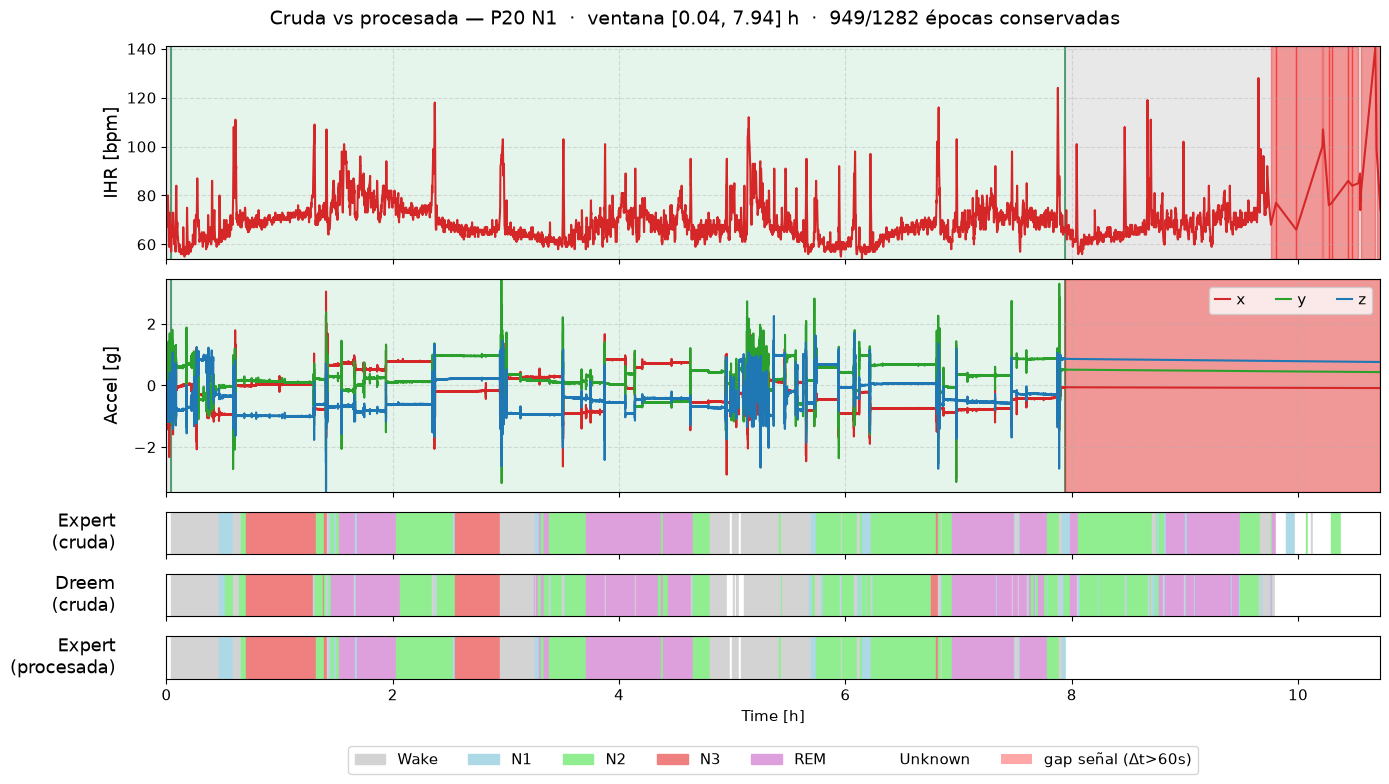

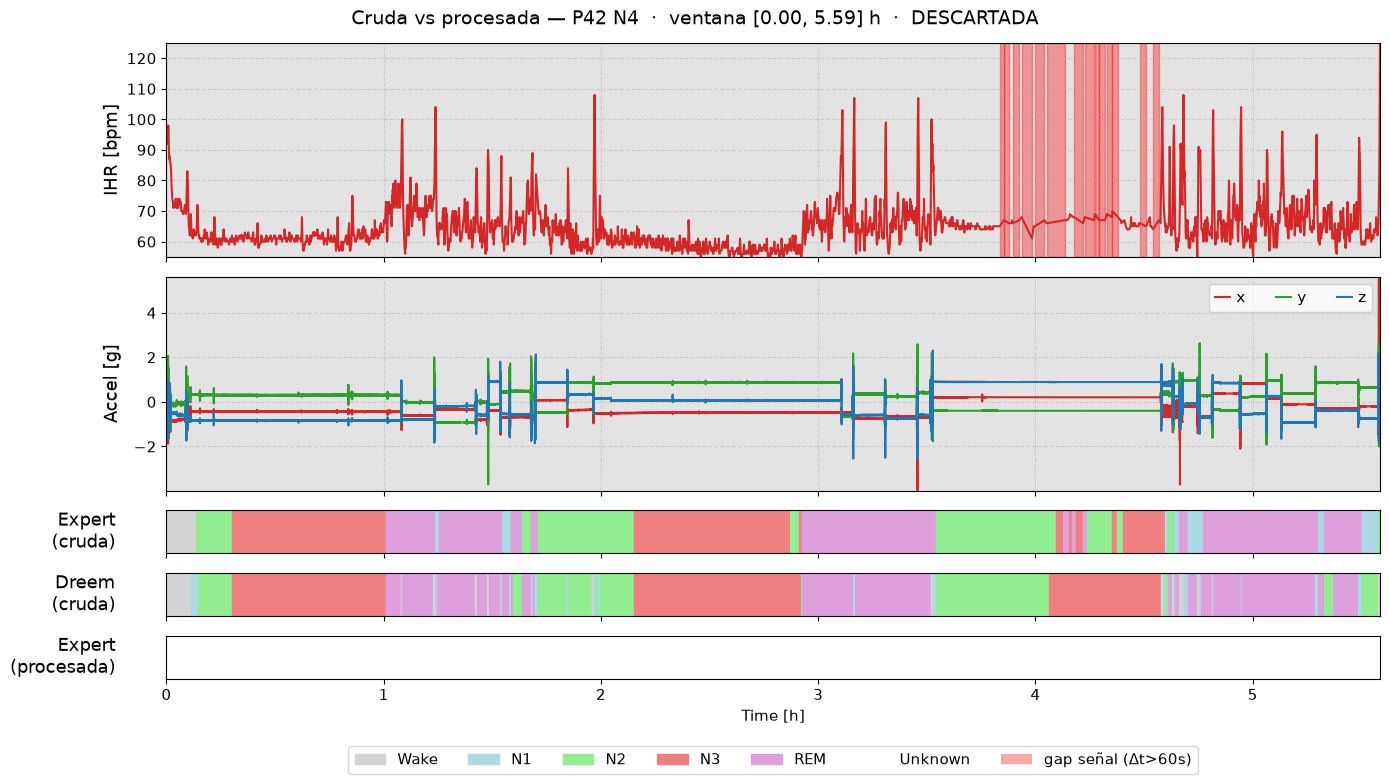

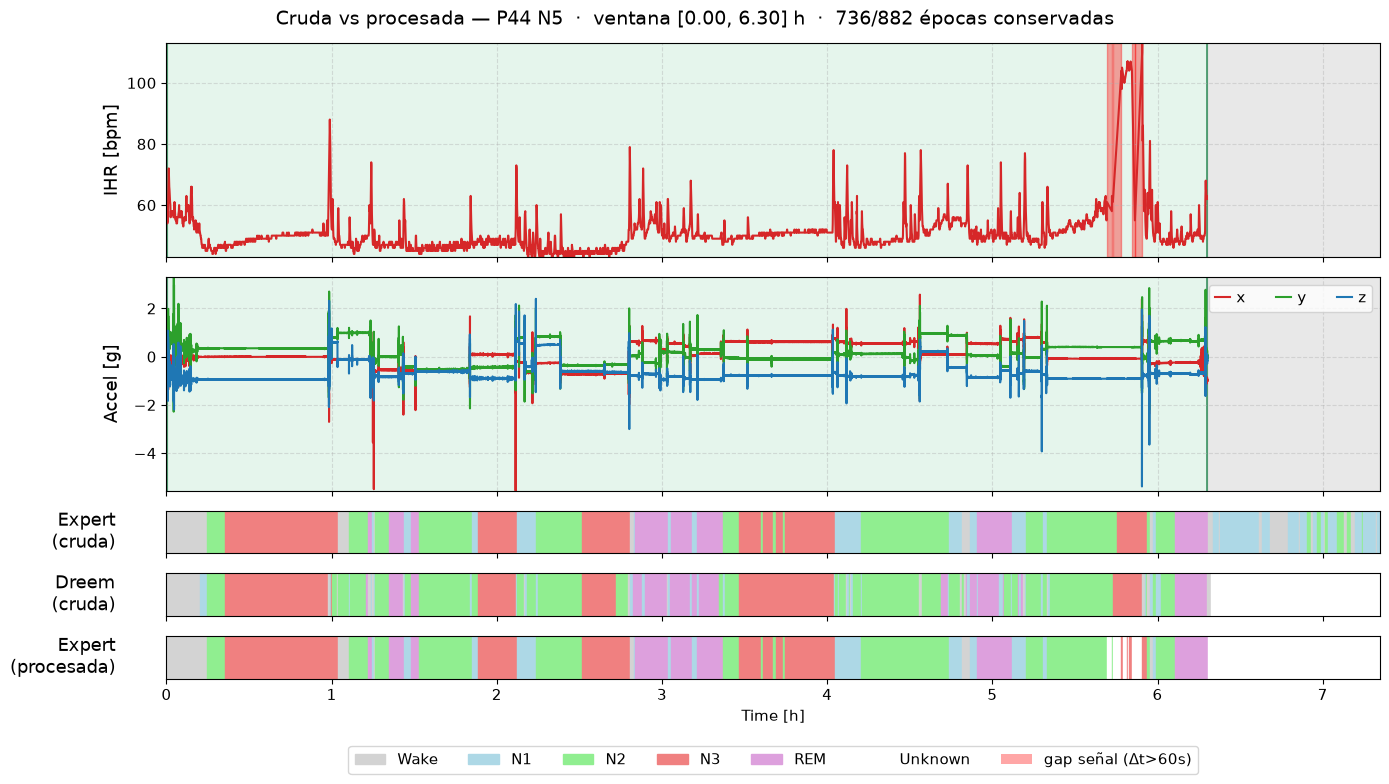

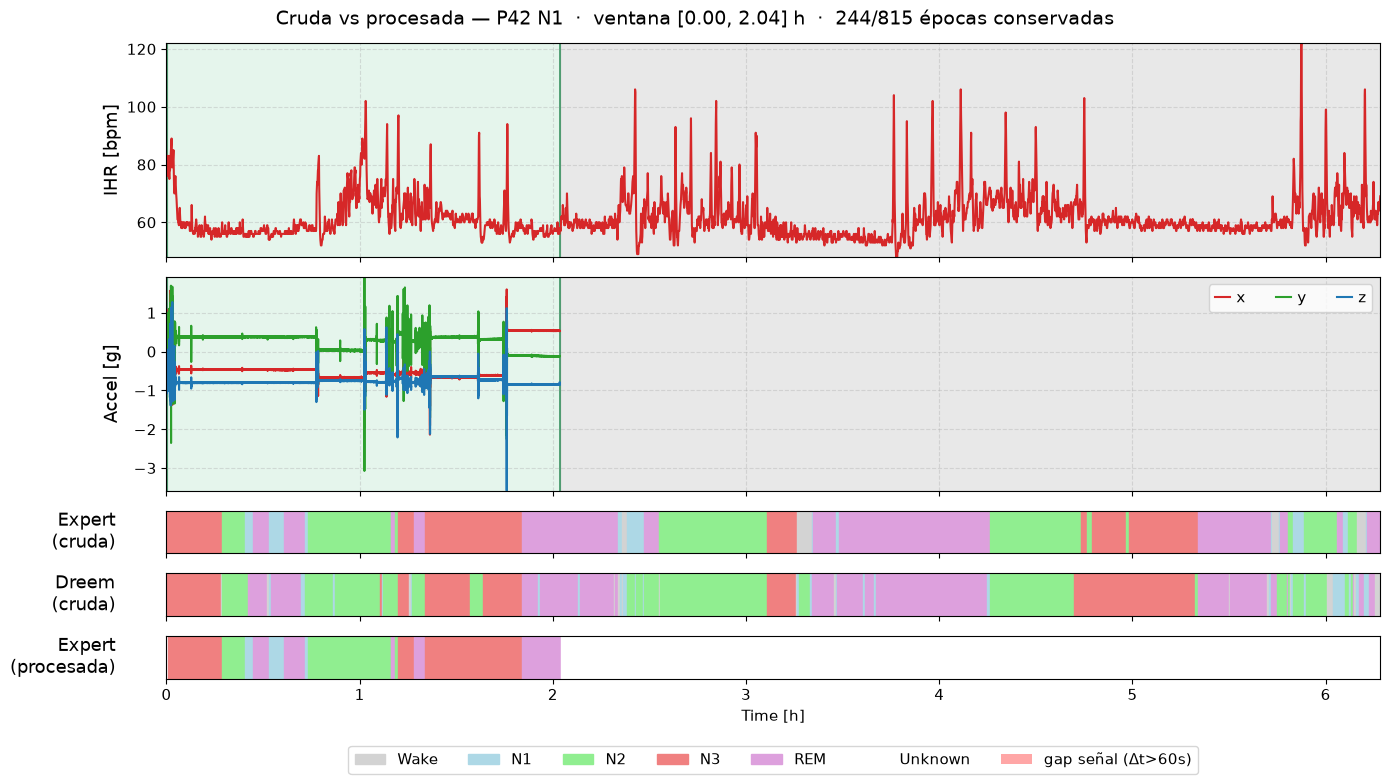

In [17]:
plots.raw_vs_clean_overview(20, 1) # acelerometría muere antes que el IHR -> ventana recortada
plots.raw_vs_clean_overview(42, 4) # gap interno de IHR -> noche descartada
plots.raw_vs_clean_overview(44, 5)
plots.raw_vs_clean_overview(42, 1)

### Distribución de Etapas de Sueño

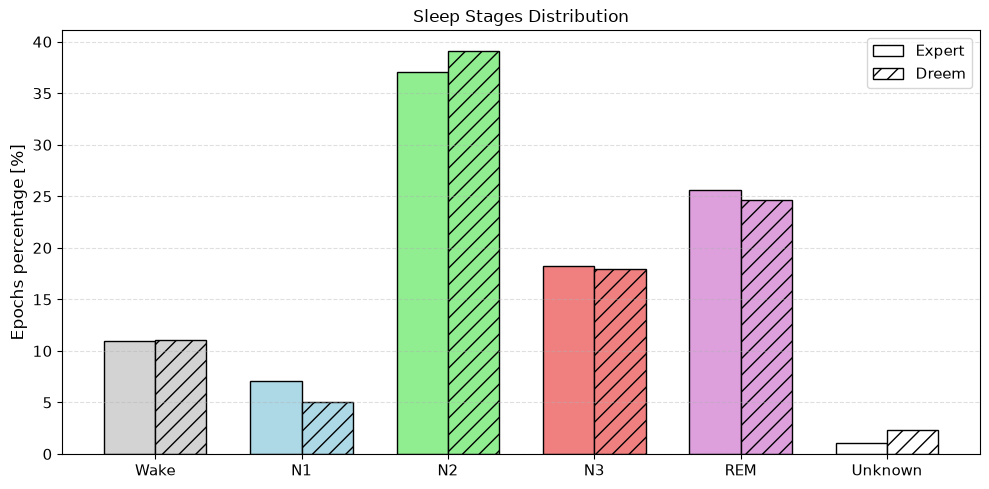

In [10]:
distributions = EDA.class_distribution()
plots.class_distribution(distributions)

### Labels **Expert** vs **Dreem**

**Cohen's Kappa** mide el *acuerdo* entre dos clasificadores (en este caso, el etiquetado del experto y el del dispositivo Dreem) corrigiendo por el acuerdo que se esperaría por azar dado el desbalance de clases (Cohen, 1960). Se define como:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

donde:
- $p_o$ es la **proporción observada de acuerdo** (accuracy): fracción de epochs donde ambos etiquetados coinciden.
- $p_e$ es la **proporción de acuerdo esperada por azar**, calculada a partir de las distribuciones marginales de cada clasificador: $p_e = \sum_k \frac{n_{k\cdot} \cdot n_{\cdot k}}{n^2}$, con $n_{k\cdot}$ y $n_{\cdot k}$ las marginales de fila/columna de la matriz de confusión y $n$ el total de epochs.

**Valores que puede tomar:**
- $\kappa = 1$: acuerdo perfecto.
- $\kappa = 0$: el acuerdo observado es igual al esperado por azar (no hay acuerdo más allá del azar).
- $\kappa < 0$: el acuerdo es peor que el azar (desacuerdo sistemático).
- En general $-1 \le \kappa \le 1$.

**Interpretación habitual [(Landis & Koch, 1977)](http://doi.org/10.2307/2529310):** $<0$ sin acuerdo, $0$–$0.2$ leve, $0.2$–$0.4$ aceptable, $0.4$–$0.6$ moderado, $0.6$–$0.8$ sustancial, $0.8$–$1$ casi perfecto.

Además del valor global, se calcula $\kappa$ **por clase** mediante un esquema one-vs-rest: para cada etapa $k$ se binariza el problema (¿es clase $k$ o no?) y se computa $\kappa$ sobre esa matriz de confusión 2x2, lo que permite identificar en qué etapas específicas el experto y Dreem difieren más.

In [11]:
expert, dreem = EDA.all_labels()
kappa_global = cohen_kappa_score(expert, dreem)
kappa_per_class = metrics.cohen_kappa_per_class(expert, dreem)

labels = ['K (global)'] + [f'K ({stage})' for stage in STAGES_LABELS.values()]
label_width = max(len(l) for l in labels)

print(f'{labels[0]:<{label_width}} = {kappa_global:.4f}')
for label, k in zip(labels[1:], kappa_per_class):
    print(f'{label:<{label_width}} = {k:.4f}')

K (global) = 0.7411
K (Wake)   = 0.7031
K (N1)     = 0.1318
K (N2)     = 0.7317
K (N3)     = 0.9031
K (REM)    = 0.8453
K (Unkown) = 0.5572


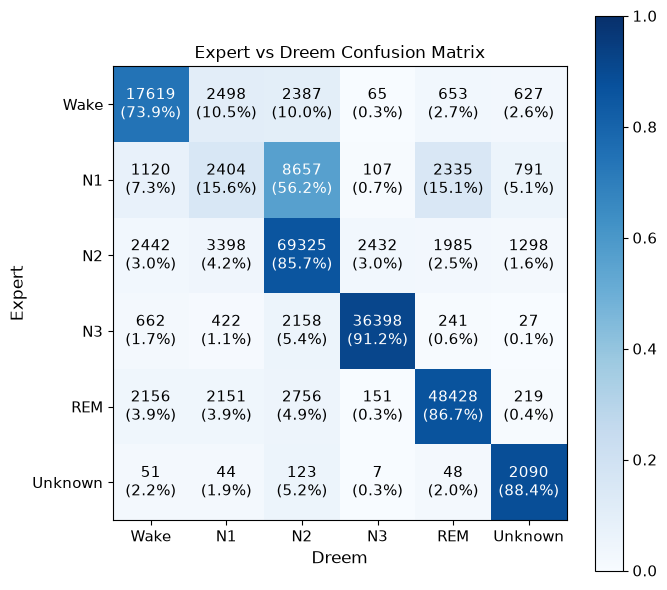

In [12]:
cm = confusion_matrix(expert, dreem, labels=range(6))
plots.confusion_matrix(cm)